### Step 1: Upload your Excel file
This will open a file selection dialog. Choose your Excel file from your local machine.

In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

Saving sustainability data set.xlsx to sustainability data set.xlsx


### Step 2: Read the uploaded Excel file into a pandas DataFrame
Once uploaded, the `uploaded` variable will contain the file content. We'll read the first uploaded file.

In [ ]:
# Get the name of the first uploaded file
file_name = next(iter(uploaded))
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# Display the first 5 rows to confirm it loaded correctly
print(f"Successfully loaded '{file_name}'")
display(df.head())

Successfully loaded 'InteractiveSheet_2026-03-18_17_01_32.xlsx'


,Year,Month,City,Energy_Consumption,Waste_Generated,Renewable_Energy,Population
0,2000,1,Ahmedabad,386,88,63,1446273
1,2000,2,Ahmedabad,254,160,33,766997
2,2000,3,Ahmedabad,268,105,42,1083417
3,2000,4,Ahmedabad,235,197,71,1179418
4,2000,5,Ahmedabad,564,122,49,1193264


Saving InteractiveSheet_2026-03-18_17_01_32.xlsx to InteractiveSheet_2026-03-18_17_01_32 (1).xlsx
First 5 rows data 👇
   Year  Month       City  Energy_Consumption  Waste_Generated  \
0  2000      1  Ahmedabad                 386               88   
1  2000      2  Ahmedabad                 254              160   
2  2000      3  Ahmedabad                 268              105   
3  2000      4  Ahmedabad                 235              197   
4  2000      5  Ahmedabad                 564              122   

   Renewable_Energy  Population  
0                63     1446273  
1                33      766997  
2                42     1083417  
3                71     1179418  
4                49     1193264  

Column names 👇
Index(['Year', 'Month', 'City', 'Energy_Consumption', 'Waste_Generated',
       'Renewable_Energy', 'Population'],
      dtype='object')


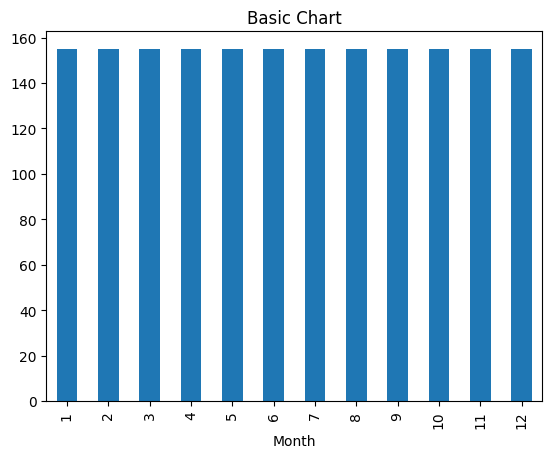

In [ ]:
# ✅ Step 1 – Upload Excel file
from google.colab import files
uploaded = files.upload()

# ✅ Step 2 – Import library
import pandas as pd
import io

# ✅ Step 3 – Read Excel file (IMPORTANT: read_excel use karvu)
file_name = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# ✅ Step 4 – Data check
print("First 5 rows data 👇")
print(df.head())

print("\nColumn names 👇")
print(df.columns)

# ✅ Step 5 – Simple chart (example)
import matplotlib.pyplot as plt

df.iloc[:,1].value_counts().plot(kind='bar')
plt.title("Basic Chart")
plt.show()

In [ ]:
import os

# Get the name of the most recently uploaded file
old_name = next(iter(uploaded))
os.rename(old_name, "data.xlsx")

print(f"Successfully renamed '{old_name}' to 'data.xlsx'")

Successfully renamed 'InteractiveSheet_2026-03-18_17_01_32 (1).xlsx' to 'data.xlsx'


In [ ]:
import os

# Get the name of the most recently uploaded file
old_name = next(iter(uploaded))
os.rename(old_name, "data.xlsx")

print(f"Successfully renamed '{old_name}' to 'data.xlsx'")

FileNotFoundError: [Errno 2] No such file or directory: 'InteractiveSheet_2026-03-18_17_01_32 (1).xlsx' -> 'data.xlsx'

In [ ]:
import pandas as pd

# load excel file
df = pd.read_excel("/content/InteractiveSheet_2026-03-18_17_01_32 (2).xlsx")

# check data
df.head()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

city_energy = df.groupby("City")["Energy_Consumption"].sum()
year_energy = df.groupby("Year")["Energy_Consumption"].sum()

fig = make_subplots(rows=2, cols=2,
                    specs=[[{"type":"indicator"},{"type":"pie"}],
                           [{"type":"bar"},{"type":"scatter"}]])

# KPI
fig.add_trace(go.Indicator(
    mode="number",
    value=df["Energy_Consumption"].sum(),
    title={"text":"Total Energy Consumption"}),
    row=1,col=1)

# Pie
fig.add_trace(go.Pie(
    labels=["Renewable","Waste"],
    values=[df["Renewable_Energy"].sum(),
            df["Waste_Generated"].sum()]),
    row=1,col=2)

# Bar
fig.add_trace(go.Bar(
    x=city_energy.index,
    y=city_energy.values),
    row=2,col=1)

# Line
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers"),
    row=2,col=2)

fig.update_layout(title="Sustainability Dashboard",height=700)

fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ===== Load Excel Dataset =====
df = pd.read_excel("sustainability data set.xlsx")

# ===== Data Processing =====
total_energy = df["Energy_Consumption"].sum()
total_waste = df["Waste_Generated"].sum()
total_renew = df["Renewable_Energy"].sum()
total_pop = df["Population"].sum()

city_energy = df.groupby("City")["Energy_Consumption"].sum()
year_energy = df.groupby("Year")["Energy_Consumption"].sum()

# ===== Dashboard Layout =====
fig = make_subplots(
    rows=3, cols=2,
    specs=[[{"type":"indicator"},{"type":"indicator"}],
           [{"type":"pie"},{"type":"bar"}],
           [{"colspan":2,"type":"scatter"}, None]],
    subplot_titles=(
        "⚡ Total Energy KPI",
        "♻ Renewable Energy KPI",
        "Waste Distribution",
        "City Energy Comparison",
        "Yearly Energy Trend"
    )
)

# KPI Energy
fig.add_trace(go.Indicator(
    mode="number",
    value=total_energy,
    title={"text":"Energy Consumption"},
    number={"font":{"size":40,"color":"green"}}
), row=1, col=1)

# KPI Renewable
fig.add_trace(go.Indicator(
    mode="number",
    value=total_renew,
    title={"text":"Renewable Energy"},
    number={"font":{"size":40,"color":"darkgreen"}}
), row=1, col=2)

# Pie Waste
fig.add_trace(go.Pie(
    labels=["Waste Generated","Renewable"],
    values=[total_waste,total_renew],
    hole=0.5,
    marker_colors=["red","green"]
), row=2, col=1)

# Bar City
fig.add_trace(go.Bar(
    x=city_energy.index,
    y=city_energy.values,
    marker_color="green"
), row=2, col=2)

# Line Trend
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers",
    line=dict(color="darkgreen", width=4)
), row=3, col=1)

fig.update_layout(
    height=900,
    title="🌱 Smart Industrial Sustainability Dashboard",
    template="plotly_white"
)

fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# load excel
import plotly.graph_objects as go
from plotly.subplots import make_subplots

city_energy = df.groupby("City")["Energy_Consumption"].sum()
year_energy = df.groupby("Year")["Energy_Consumption"].sum()

fig = make_subplots(rows=2, cols=2,
                    specs=[[{"type":"indicator"},{"type":"pie"}],
                           [{"type":"bar"},{"type":"scatter"}]])

# KPI
fig.add_trace(go.Indicator(
    mode="number",
    value=df["Energy_Consumption"].sum(),
    title={"text":"Total Energy Consumption"}),
    row=1,col=1)

# Pie
fig.add_trace(go.Pie(
    labels=["Renewable","Waste"],
    values=[df["Renewable_Energy"].sum(),
            df["Waste_Generated"].sum()]),
    row=1,col=2)

# Bar
fig.add_trace(go.Bar(
    x=city_energy.index,
    y=city_energy.values),
    row=2,col=1)

# Line
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers"),
    row=2,col=2)

fig.update_layout(title="Sustainability Dashboard",height=700)

fig.show()

# calculations
total_recycle = df["Renewable_Energy"].sum()
total_waste = df["Waste_Generated"].sum()
total_energy = df["Energy_Consumption"].sum()

year_energy = df.groupby("Year")["Energy_Consumption"].sum()

# layout
fig = make_subplots(
    rows=3, cols=3,
    specs=[
        [{"type":"indicator"},{"type":"indicator"},{"type":"indicator"}],
        [{"colspan":2,"type":"pie"},None,{"type":"bar"}],
        [{"colspan":3,"type":"scatter"},None,None]
    ],
    subplot_titles=(
        "Recycled YTD",
        "Waste Generated",
        "Total Energy",
        "Recycle vs Waste",
        "City Energy",
        "CO2 / Energy Trend"
    )
)

# KPI boxes
fig.add_trace(go.Indicator(
    mode="number",
    value=total_recycle,
    number={'font':{'size':45,'color':'green'}}
),row=1,col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_waste,
    number={'font':{'size':45,'color':'orange'}}
),row=1,col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_energy,
    number={'font':{'size':45,'color':'darkblue'}}
),row=1,col=3)

# donut
fig.add_trace(go.Pie(
    labels=["Recycled","Waste"],
    values=[total_recycle,total_waste],
    hole=0.6,
    marker_colors=["green","red"],
    textinfo="percent"
),row=2,col=1)

# category bar
city_energy = df.groupby("City")["Energy_Consumption"].sum()

fig.add_trace(go.Bar(
    x=city_energy.index,
    y=city_energy.values,
    marker_color=["green","blue","orange","red","purple"]
),row=2,col=3)

# trend
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers",
    fill="tozeroy",
    line=dict(color="green",width=4)
),row=3,col=1)

fig.update_layout(
    height=900,
    title={
        'text':"Industrial Sustainability Waste Management Dashboard",
        'x':0.5,
        'font':{'size':28}
    },
    paper_bgcolor="#f2f2f2"
)

fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ===== LOAD DATA (auto detect csv/excel) =====

df = pd.read_excel(file)

# ===== DATA PREP =====
city_energy = df.groupby("City")["Energy_Consumption"].sum()
year_energy = df.groupby("Year")["Energy_Consumption"].sum()

total_energy = df["Energy_Consumption"].sum()
total_waste = df["Waste_Generated"].sum()
total_renew = df["Renewable_Energy"].sum()

# ===== DASHBOARD LAYOUT =====
fig = make_subplots(
    rows=3, cols=3,
    specs=[
        [{"colspan":2,"type":"pie"},None,{"type":"indicator"}],
        [{"type":"bar"},{"type":"bar"},{"type":"bar"}],
        [{"colspan":3,"type":"scatter"},None,None]
    ],
    subplot_titles=(
        "Energy vs Waste Distribution",
        "Total Responses / Energy KPI",
        "City Energy Usage",
        "Waste Generated",
        "Renewable Energy",
        "Yearly Sustainability Trend"
    )
)

# donut
fig.add_trace(go.Pie(
    labels=["Energy","Waste","Renewable"],
    values=[total_energy,total_waste,total_renew],
    hole=0.6,
    marker_colors=["#00d4ff","#ff4d4d","#00ff88"],
    textinfo="percent"
),row=1,col=1)

# KPI
fig.add_trace(go.Indicator(
    mode="number",
    value=total_energy,
    number={"font":{"size":60,"color":"#00ffcc"}},
    title={"text":"Total Energy"}
),row=1,col=3)

# bars
fig.add_trace(go.Bar(
    x=city_energy.index,
    y=city_energy.values,
    marker_color="#00ffcc"
),row=2,col=1)

fig.add_trace(go.Bar(
    x=df["Year"],
    y=df["Waste_Generated"],
    marker_color="#ff4d4d"
),row=2,col=2)

fig.add_trace(go.Bar(
    x=df["Year"],
    y=df["Renewable_Energy"],
    marker_color="#00ff88"
),row=2,col=3)

# trend
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers",
    fill="tozeroy",
    line=dict(color="#00ffcc",width=4)
),row=3,col=1)

# ===== DARK THEME =====
fig.update_layout(
    height=900,
    title={
        'text':"🌱 GREENOPS SUSTAINABILITY ANALYTICS DASHBOARD",
        'x':0.5,
        'font':{'size':28,'color':'#00ffcc'}
    },
    paper_bgcolor="#0b1c2c",
    plot_bgcolor="#0b1c2c",
    font=dict(color="white"),
    template="plotly_dark"
)

fig.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ===== LOAD YOUR EXCEL =====
file = "sustainability data set.xlsx" # Changed file path to 'data.xlsx'
df = pd.read_excel(file)

# ===== TOPIC WISE DATA =====
city_energy = df.groupby("City")["Energy_Consumption"].sum()
year_energy = df.groupby("Year")["Energy_Consumption"].sum()

waste_year = df.groupby("Year")["Waste_Generated"].sum()
renew_year = df.groupby("Year")["Renewable_Energy"].sum()

total_energy = df["Energy_Consumption"].sum()
total_waste = df["Waste_Generated"].sum()
total_renew = df["Renewable_Energy"].sum()

# ===== DASHBOARD LAYOUT =====
fig = make_subplots(
    rows=3, cols=3,
    specs=[
        [{"type":"indicator"},{"type":"indicator"},{"type":"indicator"}],
        [{"colspan":2,"type":"scatter"},None,{"type":"pie"}],
        [{"colspan":3,"type":"bar"},None,None]
    ],
    subplot_titles=(
        "⚡ Total Energy",
        "🗑 Total Waste",
        "🌱 Renewable Energy",
        "Energy Trend",
        "Waste vs Renewable",
        "City Wise Energy"
    )
)

# ===== KPI CARDS =====
fig.add_trace(go.Indicator(
    mode="number",
    value=total_energy,
    number={"font":{"size":50,"color":"#1abc9c"}}
),row=1,col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_waste,
    number={"font":{"size":50,"color":"#e74c3c"}}
),row=1,col=2)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_renew,
    number={"font":{"size":50,"color":"#2ecc71"}}
),row=1,col=3)

# ===== ENERGY TREND =====
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers",
    fill="tozeroy",
    line=dict(color="#1abc9c",width=4)
),row=2,col=1)

# ===== PIE =====
fig.add_trace(go.Pie(
    labels=["Waste","Renewable"],
    values=[total_waste,total_renew],
    hole=0.6,
    marker_colors=["#e74c3c","#2ecc71"]
),row=2,col=3)

# ===== CITY BAR =====
fig.add_trace(go.Bar(
    x=city_energy.index,
    y=city_energy.values,
    marker_color="#3498db"
),row=3,col=1)

# ===== THEME =====
fig.update_layout(
    height=900,
    title={
        'text':"SMART SUSTAINABILITY MANAGEMENT DASHBOARD",
        'x':0.5,
        'font':{'size':28,'color':'#2c3e50'}
    },
    paper_bgcolor="#ecf0f1",
    plot_bgcolor="white",
    font=dict(color="#2c3e50")
)

fig.show()

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(layout="wide")

# ===== LOAD DATA =====
df = pd.read_excel("InteractiveSheet_2026-03-18_17_01_32 (2).xlsx")

# ===== SIDEBAR =====
st.sidebar.title("🌱 Sustainability Menu")
city = st.sidebar.selectbox("Select City", df["City"].unique())

df_city = df[df["City"]==city]

# ===== KPI ROW =====
col1,col2,col3 = st.columns(3)

col1.metric("⚡ Total Energy", int(df_city["Energy_Consumption"].sum()))
col2.metric("🗑 Waste Generated", int(df_city["Waste_Generated"].sum()))
col3.metric("🌿 Renewable Energy", int(df_city["Renewable_Energy"].sum()))

# ===== CHART ROW =====
c1,c2 = st.columns(2)

fig1 = px.line(df_city.groupby("Year")["Energy_Consumption"].sum(),
               title="Energy Trend",
               color_discrete_sequence=["green"])

fig2 = px.pie(df_city,
              names="Year",
              values="Waste_Generated",
              title="Waste Distribution",
              color_discrete_sequence=px.colors.sequential.Teal)

c1.plotly_chart(fig1,use_container_width=True)
c2.plotly_chart(fig2,use_container_width=True)

# ===== BOTTOM BAR =====
fig3 = px.bar(df_city.groupby("Year")["Renewable_Energy"].sum(),
              title="Renewable Growth",
              color_discrete_sequence=["darkgreen"])

st.plotly_chart(fig3,use_container_width=True)

Overwriting app.py


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import plotly.express as px

# ===== LOAD DATA =====
df = pd.read_excel("sustainability data set.xlsx")

# ===== CITY LAT LONG MANUAL MAP =====
city_coords = {
    "Ahmedabad":[23.0225,72.5714],
    "Surat":[21.1702,72.8311],
    "Vadodara":[22.3072,73.1812],
    "Rajkot":[22.3039,70.8022],
    "Gandhinagar":[23.2156,72.6369]
}

df["lat"] = df["City"].map(lambda x: city_coords[x][0])
df["lon"] = df["City"].map(lambda x: city_coords[x][1])

# ===== ENERGY SUM CITY =====
city_energy = df.groupby(["City","lat","lon"])["Energy_Consumption"].sum().reset_index()

# ===== MAP =====
fig = px.scatter_mapbox(
    city_energy,
    lat="lat",
    lon="lon",
    size="Energy_Consumption",
    color="Energy_Consumption",
    hover_name="City",
    zoom=6,
    size_max=40,
    color_continuous_scale="Greens"
)

fig.update_layout(
    mapbox_style="carto-positron",
    title="🌍 Smart Sustainability Energy Map Dashboard",
    height=600
)

fig.show()

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(layout="wide")

# ===== LOAD DATA =====
df = pd.read_excel("InteractiveSheet_2026-03-18_17_01_32 (2).xlsx")

# ===== SIDEBAR =====
st.sidebar.title("📊 Smart Sustainability")
menu = st.sidebar.radio("Navigation",
                        ["Dashboard","Energy","Waste","Renewable"])

# ===== CITY LAT LONG =====
coords = {
    "Ahmedabad":[23.0225,72.5714],
    "Surat":[21.1702,72.8311],
    "Vadodara":[22.3072,73.1812],
    "Rajkot":[22.3039,70.8022],
    "Gandhinagar":[23.2156,72.6369]
}

df["lat"] = df["City"].map(lambda x: coords[x][0])
df["lon"] = df["City"].map(lambda x: coords[x][1])

city_energy = df.groupby(["City","lat","lon"])["Energy_Consumption"].sum().reset_index()

# ===== MAIN DASHBOARD =====
st.title("🌍 Smart City Sustainability Dashboard")

c1,c2 = st.columns(2)

# MAP
fig_map = px.scatter_mapbox(
    city_energy,
    lat="lat",
    lon="lon",
    size="Energy_Consumption",
    color="Energy_Consumption",
    zoom=6,
    size_max=40,
    color_continuous_scale="Viridis"
)
fig_map.update_layout(mapbox_style="open-street-map")

c1.plotly_chart(fig_map,use_container_width=True)

# TREND GRAPH
trend = df.groupby("Year")["Energy_Consumption"].sum()

fig_line = px.line(trend,title="Energy Trend")
c2.plotly_chart(fig_line,use_container_width=True)

# KPI CARDS
k1,k2,k3,k4 = st.columns(4)

k1.metric("Total Energy", int(df["Energy_Consumption"].sum()))
k2.metric("Total Waste", int(df["Waste_Generated"].sum()))
k3.metric("Renewable Energy", int(df["Renewable_Energy"].sum()))
k4.metric("Cities Covered", df["City"].nunique())

Overwriting app.py


In [ ]:
!streamlit run app.py &>/dev/null &
!npx localtunnel --port 8501

In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok
import os

# streamlit start
get_ipython().system_raw('streamlit run app.py &')

# public url create
public_url = ngrok.connect(8501)
print(public_url)

In [ ]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ===== LOAD DATA =====
df = pd.read_excel("InteractiveSheet_2026-03-18_17_01_32.xlsx")

# ===== CITY LAT LONG =====
coords = {
    "Ahmedabad":[23.0225,72.5714],
    "Surat":[21.1702,72.8311],
    "Vadodara":[22.3072,73.1812],
    "Rajkot":[22.3039,70.8022],
    "Gandhinagar":[23.2156,72.6369]
}

df["lat"] = df["City"].map(lambda x: coords[x][0])
df["lon"] = df["City"].map(lambda x: coords[x][1])

city_energy = df.groupby(["City","lat","lon"])["Energy_Consumption"].sum().reset_index()
year_energy = df.groupby("Year")["Energy_Consumption"].sum()

# ===== DASHBOARD LAYOUT =====
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type":"mapbox"},{"type":"indicator"}],
           [{"type":"bar"},{"type":"scatter"}]],
    subplot_titles=("City Energy Map","Total Energy KPI",
                    "City Comparison","Energy Trend")
)

# MAP
fig.add_trace(go.Scattermapbox(
    lat=city_energy["lat"],
    lon=city_energy["lon"],
    mode='markers',
    marker=dict(size=city_energy["Energy_Consumption"]/5000,
                color=city_energy["Energy_Consumption"],
                colorscale="Greens",
                showscale=True),
    text=city_energy["City"]
),row=1,col=1)

# KPI
fig.add_trace(go.Indicator(
    mode="number",
    value=df["Energy_Consumption"].sum(),
    number={'font':{'size':50}}
),row=1,col=2)

# BAR
fig.add_trace(go.Bar(
    x=city_energy["City"],
    y=city_energy["Energy_Consumption"],
    marker_color="green"
),row=2,col=1)

# TREND
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers",
    line=dict(color="darkgreen",width=4)
),row=2,col=2)

fig.update_layout(
    height=800,
    title="SMART CITY SUSTAINABILITY DASHBOARD",
    mapbox_style="open-street-map"
)

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'InteractiveSheet_2026-03-18_17_01_32.xlsx'

In [ ]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ===== LOAD DATA =====
df = pd.read_excel("InteractiveSheet_2026-03-18_17_01_32.xlsx")

# ===== GROUP DATA =====
year_energy = df.groupby("Year")["Energy_Consumption"].sum()
month_energy = df.groupby("Month")["Energy_Consumption"].sum()
city_energy = df.groupby("City")["Energy_Consumption"].sum()

year_waste = df.groupby("Year")["Waste_Generated"].sum()

total_energy = df["Energy_Consumption"].sum()
total_waste = df["Waste_Generated"].sum()
total_renew = df["Renewable_Energy"].sum()
total_pop = df["Population"].sum()

# ===== DASHBOARD LAYOUT =====
fig = make_subplots(
    rows=3, cols=2,
    specs=[[{"type":"indicator"},{"type":"indicator"}],
           [{"type":"bar"},{"type":"pie"}],
           [{"colspan":2,"type":"scatter"},None]],
    subplot_titles=("Total Energy","Total Waste",
                    "City Energy Comparison","Renewable Share",
                    "Yearly Energy Trend")
)

# KPI ENERGY
fig.add_trace(go.Indicator(
    mode="number",
    value=total_energy,
    number={'font':{'size':45,'color':'green'}}
),row=1,col=1)

# KPI WASTE
fig.add_trace(go.Indicator(
    mode="number",
    value=total_waste,
    number={'font':{'size':45,'color':'red'}}
),row=1,col=2)

# CITY BAR
fig.add_trace(go.Bar(
    x=city_energy.index,
    y=city_energy.values,
    marker_color="green"
),row=2,col=1)

# PIE
fig.add_trace(go.Pie(
    labels=["Renewable","Waste"],
    values=[total_renew,total_waste],
    hole=0.5
),row=2,col=2)

# YEAR TREND
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers",
    line=dict(color="darkgreen",width=4)
),row=3,col=1)

fig.update_layout(
    height=900,
    title="🌱 COMBINED SMART CITY SUSTAINABILITY DASHBOARD",
    template="plotly_white"
)

fig.show()


FileNotFoundError: [Errno 2] No such file or directory: 'InteractiveSheet_2026-03-18_17_01_32.xlsx'

In [ ]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ===== LOAD DATA =====
df = pd.read_excel("InteractiveSheet_2026-03-18_17_01_32.xlsx")

# ===== GROUPING =====
year_energy = df.groupby("Year")["Energy_Consumption"].sum()
month_energy = df.groupby("Month")["Energy_Consumption"].sum()
city_energy = df.groupby("City")["Energy_Consumption"].sum()

# totals
total_energy = df["Energy_Consumption"].sum()
total_waste = df["Waste_Generated"].sum()
total_renew = df["Renewable_Energy"].sum()

# ===== DASHBOARD =====
fig = make_subplots(
    rows=3, cols=2,
    specs=[[{"type":"indicator"},{"type":"indicator"}],
           [{"type":"bar"},{"type":"scatter"}],
           [{"colspan":2,"type":"scatter"},None]],
    subplot_titles=("Total Energy","Total Renewable",
                    "City Energy","Population vs Energy",
                    "Yearly Trend")
)

# KPI
fig.add_trace(go.Indicator(
    mode="number",
    value=total_energy,
    number={'font':{'size':45,'color':'green'}}
),row=1,col=1)

fig.add_trace(go.Indicator(
    mode="number",
    value=total_renew,
    number={'font':{'size':45,'color':'darkgreen'}}
),row=1,col=2)

# city bar
fig.add_trace(go.Bar(
    x=city_energy.index,
    y=city_energy.values,
    marker_color="green"
),row=2,col=1)

# population scatter
fig.add_trace(go.Scatter(
    x=df["Population"],
    y=df["Energy_Consumption"],
    mode="markers",
    marker=dict(color="orange",size=8)
),row=2,col=2)

# yearly trend
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers",
    line=dict(color="darkgreen",width=4)
),row=3,col=1)

fig.update_layout(
    height=900,
    title="SMART CITY SUSTAINABILITY ANALYTICS DASHBOARD",
    paper_bgcolor="#f4f6f7"
)

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'InteractiveSheet_2026-03-18_17_01_32.xlsx'

In [ ]:
import pandas as pd
import plotly.express as px

# ===== LOAD DATA =====
df = pd.read_excel("InteractiveSheet_2026-03-18_17_01_32.xlsx")

# advanced scatter bubble
fig = px.scatter(
    df,
    x="Population",
    y="Energy_Consumption",
    size="Renewable_Energy",
    color="City",
    hover_data=["Year","Month","Waste_Generated"],
    title="Population vs Energy Consumption Analysis",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    height=600,
    paper_bgcolor="#f8f9f9"
)

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'InteractiveSheet_2026-03-18_17_01_32.xlsx'

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ===== LOAD DATA =====
df = pd.read_excel("InteractiveSheet_2026-03-18_17_01_32.xlsx")

# ===== DATA PREP =====
city_energy = df.groupby("City")["Energy_Consumption"].sum()
year_energy = df.groupby("Year")["Energy_Consumption"].sum()

total_energy = df["Energy_Consumption"].sum()
total_waste = df["Waste_Generated"].sum()
total_renew = df["Renewable_Energy"].sum()

# ===== DASHBOARD LAYOUT =====
fig = make_subplots(
    rows=3, cols=3,
    specs=[
        [{"colspan":2,"type":"pie"},None,{"type":"indicator"}],
        [{"type":"bar"},{"type":"bar"},{"type":"bar"}],
        [{"colspan":3,"type":"scatter"},None,None]
    ],
    subplot_titles=(
        "Energy vs Waste Distribution",
        "Total Responses / Energy KPI",
        "City Energy Usage",
        "Waste Generated",
        "Renewable Energy",
        "Yearly Sustainability Trend"
    )
)

# donut
fig.add_trace(go.Pie(
    labels=["Energy","Waste","Renewable"],
    values=[total_energy,total_waste,total_renew],
    hole=0.6,
    marker_colors=["#00d4ff","#ff4d4d","#00ff88"],
    textinfo="percent"
),row=1,col=1)

# KPI
fig.add_trace(go.Indicator(
    mode="number",
    value=total_energy,
    number={"font":{"size":60,"color":"#00ffcc"}},
    title={"text":"Total Energy"}
),row=1,col=3)

# bars
fig.add_trace(go.Bar(
    x=city_energy.index,
    y=city_energy.values,
    marker_color="#00ffcc"
),row=2,col=1)

fig.add_trace(go.Bar(
    x=df["Year"],
    y=df["Waste_Generated"],
    marker_color="#ff4d4d"
),row=2,col=2)

fig.add_trace(go.Bar(
    x=df["Year"],
    y=df["Renewable_Energy"],
    marker_color="#00ff88"
),row=2,col=3)

# trend
fig.add_trace(go.Scatter(
    x=year_energy.index,
    y=year_energy.values,
    mode="lines+markers",
    fill="tozeroy",
    line=dict(color="#00ffcc",width=4)
),row=3,col=1)

# ===== DARK THEME =====
fig.update_layout(
    height=900,
    title={
        'text':"🌱 GREENOPS SUSTAINABILITY ANALYTICS DASHBOARD",
        'x':0.5,
        'font':{'size':28,'color':'#00ffcc'}
    },
    paper_bgcolor="#0b1c2c",
    plot_bgcolor="#0b1c2c",
    font=dict(color="white"),
    template="plotly_dark"
)

fig.show()

FileNotFoundError: [Errno 2] No such file or directory: 'InteractiveSheet_2026-03-18_17_01_32.xlsx'

In [ ]:
import os
os.listdir()

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Smart Dashboard", layout="wide")

st.title("🌱 Smart Sustainability Dashboard")

# Load Excel


# Sidebar
st.sidebar.title("Filters")
city = st.sidebar.selectbox("Select City", df["City"].unique())

filtered_df = df[df["City"] == city]

# KPI Cards
col1, col2, col3 = st.columns(3)

col1.metric("Energy", int(filtered_df["Energy_Consumption"].sum()))
col2.metric("Waste", int(filtered_df["Waste_Generated"].sum()))
col3.metric("Renewable", int(filtered_df["Renewable_Energy"].sum()))

st.markdown("---")

# Charts
st.subheader("📊 Charts")

fig1 = px.bar(filtered_df, x="City", y="Energy_Consumption",
              color="Energy_Consumption", title="Energy Consumption")
st.plotly_chart(fig1, use_container_width=True)

fig2 = px.line(filtered_df, x="City", y="Waste_Generated",
               title="Waste Generated")
st.plotly_chart(fig2, use_container_width=True)

fig3 = px.pie(filtered_df, names="City", values="Renewable_Energy",
              title="Renewable Energy Share")
st.plotly_chart(fig3, use_container_width=True)

Overwriting app.py


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import os

# change filename automatically
old_name = list(uploaded.keys())[0]
os.rename(old_name, "data.xlsx")

print("Renamed to data.xlsx")

In [ ]:
!pip install streamlit pyngrok plotly openpyxl

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Smart Dashboard", layout="wide")

st.title("🌱 Smart Sustainability Dashboard")

# Load Excel
df = pd.read_excel("InteractiveSheet_2026-03-18_17_01_32.xlsx")

# Sidebar
st.sidebar.title("Filters")
city = st.sidebar.selectbox("Select City", df["City"].unique())

filtered_df = df[df["City"] == city]

# KPI Cards
col1, col2, col3 = st.columns(3)

col1.metric("Energy", int(filtered_df["Energy_Consumption"].sum()))
col2.metric("Waste", int(filtered_df["Waste_Generated"].sum()))
col3.metric("Renewable", int(filtered_df["Renewable_Energy"].sum()))

st.markdown("---")

# Charts
st.subheader("📊 Charts")

fig1 = px.bar(filtered_df, x="City", y="Energy_Consumption",
              color="Energy_Consumption", title="Energy Consumption")
st.plotly_chart(fig1, use_container_width=True)

fig2 = px.line(filtered_df, x="City", y="Waste_Generated",
               title="Waste Generated")
st.plotly_chart(fig2, use_container_width=True)

fig3 = px.pie(filtered_df, names="City", values="Renewable_Energy",
              title="Renewable Energy Share")
st.plotly_chart(fig3, use_container_width=True)

Writing app.py
